In [28]:
import numpy as np
from scipy.optimize import linprog
import pandas as pd
import pulp
import networkx as nx
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
from joblib import Parallel, delayed

## 1. Récupération des données

### a. Chargement des données pour 1 pays du code jouet

In [29]:
# Chargement des données
df_solar = pd.read_csv('solar.csv')
df_wind = pd.read_csv('wind_onshore.csv')
df_demand = pd.read_csv('demand2050_ADEME.csv', header=None)
df_demand.columns = ["heures", "demande"]

# Calcul consommation annuelle
annual_demand = df_demand['demande'].sum()

# Calcul production potentielle pour 1GW installé
annual_solar_per_gw = df_solar['facteur_charge'].sum()
annual_wind_per_gw = df_wind['facteur_charge'].sum()

# Pour avoir 100% de surproduction et un mix 50-50
target_production = annual_demand * 3.5
wind_capacity = target_production/(2 * annual_wind_per_gw)
solar_capacity = target_production/(2 * annual_solar_per_gw)

print(f"Capacités requises: éolien = {wind_capacity:.1f}GW, solaire = {solar_capacity:.1f}GW")

Capacités requises: éolien = 297.6GW, solaire = 539.7GW


### b. Tranformation pour simuler 5 pays différents

In [30]:
T = len(df_demand)
N=5

assert T % N == 0, "T doit être divisible par N"

demand_1 = df_demand['demande'].values*2.5 # shape (T,)
demand_N = demand_1.reshape(N, T // N)

solar_1 = df_solar['facteur_charge'].values
solar_N = solar_1.reshape(N, T // N)

wind_1  = df_wind['facteur_charge'].values
wind_N  = wind_1.reshape(N, T // N)

demand_N = demand_N.T    # shape (T/N, N)
solar_N  = solar_N.T
wind_N   = wind_N.T

wind_cap_N  = np.full(N, wind_capacity)
solar_cap_N = np.full(N, solar_capacity)

### c. Chargement des valeurs d'échange maximales

In [31]:
qmax11pays = np.array([[0 ,50,20,30,40,70,20,30,50,40,70],
                       [50,0 ,80,40,30,20,50,0 ,70,60,30],
                       [20,80,0 ,60,50,60,40,30,70,50,20],
                       [30,40,60,0 ,40,60,0 ,40,60,0 ,40],
                       [40,30,50,40,0 ,40,30,70,60,80,70],
                       [70,20,60,60,40,0 ,20,30,20,60,60],
                       [20,50,40,0 ,30,20,0 ,40,50,60,40],
                       [30,0 ,30,40,70,30,40,0 ,30,70,50],
                       [50,70,70,60,60,20,50,30,0 ,30,60],
                       [40,60,50,0 ,80,60,60,70,30,0 ,30],
                       [70,30,20,40,70,60,40,50,60,30,0 ]])

qmax = qmax11pays[:N,:N]

## 2. Définition du problème

## a. Code optimisation stockage 1 pays

In [32]:
def optimize_storage(prod, demand,
                    phs_capacity, phs_power, phs_eff,
                    ptg_capacity, ptg_power_in, ptg_power_out, 
                    ptg_eff, penalisation):
    """
    Optimise la stratégie de stockage sur l'année avec contrainte cyclique
    
    Parameters:
    -----------
    solar_profile, wind_profile: séries temporelles des facteurs de charge
    demand: série temporelle de la demande
    wind_cap, solar_cap: capacités installées en GW
    phs_capacity: capacité de stockage PHS en GWh
    phs_power: puissance max PHS en GW
    phs_eff: rendement PHS (aller-retour)
    ptg_capacity: capacité de stockage P2G en GWh
    ptg_power_in: puissance max électrolyse en GW  
    ptg_power_out: puissance max reconversion en GW
    ptg_eff: rendement P2G (aller-retour)
    """
    
    T = len(demand)  # nombre d'heures
    
    # Création du problème
    prob = pulp.LpProblem("Storage_Strategy", pulp.LpMinimize)
    
    # Variables
    phs_in = pulp.LpVariable.dicts("phs_in", range(T), 0)  # Charge PHS
    phs_out = pulp.LpVariable.dicts("phs_out", range(T), 0)  # Décharge PHS
    phs_level = pulp.LpVariable.dicts("phs_level", range(T), 0)  # Niveau PHS
    
    ptg_in = pulp.LpVariable.dicts("ptg_in", range(T), 0)  # Charge P2G
    ptg_out = pulp.LpVariable.dicts("ptg_out", range(T), 0)  # Décharge P2G
    ptg_level = pulp.LpVariable.dicts("ptg_level", range(T), 0)  # Niveau P2G
    
    deficit = pulp.LpVariable.dicts("deficit", range(T), 0)  # Déficit
    surplus = pulp.LpVariable.dicts("surplus", range(T), lowBound=0) # Surplus
    
    
    # Fonction objectif : minimiser déficits
    prob += -ptg_level[T-1] + penalisation * pulp.lpSum(deficit[t] for t in range(T))
    
    # Contraintes
    
    # Niveaux initiaux
    prob += phs_level[0] == phs_capacity/2  # PHS à 50%
    prob += ptg_level[0] == ptg_capacity    # P2G plein
    
    # Contraintes cycliques : les niveaux finaux doivent être égaux aux niveaux initiaux
    #prob += phs_level[T-1] == phs_level[0]
    #prob += ptg_level[T-1] == ptg_level[0]
    
    for t in range(T):
        # Équilibre offre-demande
        prob += (
                prod[t] 
                + phs_out[t] * phs_eff 
                + ptg_out[t] * ptg_eff 
                + deficit[t]
                == 
                demand[t] 
                + phs_in[t] 
                + ptg_in[t]
                + surplus[t]
        )
        
        # Limites PHS
        prob += phs_in[t] <= phs_power
        prob += phs_out[t] <= phs_power
        prob += phs_level[t] <= phs_capacity
        
        # Limites P2G
        prob += ptg_in[t] <= ptg_power_in
        prob += ptg_out[t] <= ptg_power_out
        prob += ptg_level[t] <= ptg_capacity
        
        # Évolution des stocks
        if t > 0:
            prob += phs_level[t] == phs_level[t-1] + phs_in[t]*phs_eff - phs_out[t]
            prob += ptg_level[t] == ptg_level[t-1] + ptg_in[t]*ptg_eff - ptg_out[t]
       
        
    # Résolution
    prob.solve()
    
    return {
        'status': pulp.LpStatus[prob.status],
        'prod':prod,
        'phs_in': [phs_in[t].value() for t in range(T)],
        'phs_out': [phs_out[t].value() for t in range(T)],
        'phs_level': [phs_level[t].value() for t in range(T)],
        'ptg_in': [ptg_in[t].value() for t in range(T)],
        'ptg_out': [ptg_out[t].value() for t in range(T)],
        'ptg_level': [ptg_level[t].value() for t in range(T)],
        'deficit': [deficit[t].value() for t in range(T)],
        'surplus': [surplus[t].value() for t in range(T)]
    }


## b. Code optimisation des échanges n pays

In [33]:
def solve_flux_interval(dispo, qmax_matrix, flux_eff, targets, penalisation=1e10):
    T, N = dispo.shape
    prob = pulp.LpProblem("Flux_Interval_Target", pulp.LpMinimize)

    # 1. Variables de flux : On ne crée que si i != j
    q = {}
    for t in range(T):
        for i in range(N):
            for j in range(N):
                if i != j:
                    q[t, i, j] = pulp.LpVariable(
                        f"q_{t}_{i}_{j}",
                        lowBound=0,
                        upBound=float(qmax_matrix[i, j])
                    )

    # 2. Variables de dépassement (Slacks)
    # over : surplus qui dépasse target_max
    # under : déficit qui tombe sous target_min
    over = pulp.LpVariable.dicts("over", (range(T), range(N)), lowBound=0)
    under = pulp.LpVariable.dicts("under", (range(T), range(N)), lowBound=0)

    # 3. Fonction Objectif
    # Minimiser les dépassements d'intervalle. 
    # Optionnel : + 0.001 * q pour éviter les flux circulaires inutiles
    prob += pulp.lpSum(penalisation * (over[t][i] + under[t][i]) 
                       for t in range(T) for i in range(N))

    # 4. Contraintes de bilan
    for t in range(T):
        for i in range(N):
            t_min, t_max = targets[i]
            
            # Somme des flux entrants et sortants (uniquement si la clé existe)
            inflow = pulp.lpSum(q[t, j, i] for j in range(N) if i != j)
            outflow = pulp.lpSum(q[t, i, j] for j in range(N) if i != j)
            
            # Balance finale = balance initiale + imports_nets
            balance_f = dispo[t, i] + (flux_eff * inflow) - outflow
            
            # Contraintes d'intervalle "souples" (Soft Constraints)
            # balance_f - over <= target_max  => si balance > max, over devient > 0
            # balance_f + under >= target_min => si balance < min, under devient > 0
            prob += balance_f - over[t][i] <= t_max
            prob += balance_f + under[t][i] >= t_min

    # Résolution
    solver = pulp.PULP_CBC_CMD(msg=False)
    prob.solve(solver)

    # Extraction des résultats
    q_res = np.zeros((T, N, N))
    final_balances = np.zeros((T, N))
    
    for t in range(T):
        for i in range(N):
            for j in range(N):
                if i != j:
                    q_res[t, i, j] = pulp.value(q[t, i, j])
            
            # Recalcul de la balance finale réelle
            inf = sum(q_res[t, j, i] for j in range(N) if i != j)
            outf = sum(q_res[t, i, j] for j in range(N) if i != j) # erreur ici corrigée dessous
            # Correction :
            outf = sum(q_res[t, i, j] for j in range(N) if i != j)
            final_balances[t, i] = dispo[t, i] + (flux_eff * inf) - outf

    return {
        'flux': q_res,
        'balances_finales': final_balances
    }

## c. Combiner les deux optimisations

In [34]:
def optimize(
    wind_profile, solar_profile, demand,
    wind_cap, solar_cap, qmax_matrix,
    phs_capacity=180, phs_power=9.3, phs_eff=0.75,
    ptg_capacity=125000, ptg_power_in=7.66, ptg_power_out=32.93,
    ptg_eff=0.4, penalisation=1e10, flux_eff=0.9
):

    T, N = demand.shape
    
    # 1 - Calcul de la production et des disponibilitées
    prod = (wind_cap * wind_profile + solar_cap * solar_profile)
    dispo_initiale = prod - demand

    # 2 - Définition de l'intervalle cible pour chaque pays
    target_min = -(phs_power + ptg_power_in)  # Capacité à absorber le surplus
    target_max = (phs_power + ptg_power_out)  # Capacité à combler le déficit
    
    # On crée la liste des targets pour solve_flux_interval
    targets = [(target_min, target_max) for _ in range(N)]

    # 3 - Calcul des échanges pour rentrer dans ces intervalles
    result_flux = solve_flux_interval(
        dispo_initiale, 
        qmax_matrix, 
        flux_eff, 
        targets, 
        penalisation
    )

    echanges = result_flux['flux']
    balance_apres_echanges = result_flux['balances_finales']

    # 4 - Optimisation du stockage pour chaque pays
    # On sépare la balance en surplus/déficit pour rester compatible avec optimize_storage
    surplus_pour_stockage = np.maximum(0, balance_apres_echanges)
    deficit_pour_stockage = np.maximum(0, -balance_apres_echanges)

    def run_one_country(p):
        return optimize_storage(
            surplus_pour_stockage[:, p], 
            deficit_pour_stockage[:, p], 
            phs_capacity, phs_power, phs_eff, 
            ptg_capacity, ptg_power_in, ptg_power_out, ptg_eff, 
            penalisation
        )
        


    result2 = Parallel(n_jobs=-1)(delayed(run_one_country)(p) for p in range(N))

    # 5 - Rassemblement des résultats
    phs_in, phs_out, phs_level = np.zeros((T, N)), np.zeros((T, N)), np.zeros((T, N))
    ptg_in, ptg_out, ptg_level = np.zeros((T, N)), np.zeros((T, N)), np.zeros((T, N))
    deficit_final, surplus_final = np.zeros((T, N)), np.zeros((T, N))

    for p, res in enumerate(result2):
        phs_in[:, p] = res['phs_in']
        phs_out[:, p] = res['phs_out']
        phs_level[:, p] = res['phs_level']
        ptg_in[:, p] = res['ptg_in']
        ptg_out[:, p] = res['ptg_out']
        ptg_level[:, p] = res['ptg_level']
        deficit_final[:, p] = res['deficit']
        surplus_final[:, p] = res['surplus']

    return {
        'prod': prod,
        'phs_in': phs_in,
        'phs_out': phs_out,
        'phs_level': phs_level,
        'ptg_in': ptg_in,
        'ptg_out': ptg_out,
        'ptg_level': ptg_level,
        'balance_initiale': dispo_initiale,
        'balance_apres_echanges': balance_apres_echanges,
        'deficit_final': deficit_final,
        'surplus_final': surplus_final,
        'echanges': echanges
    }

## 3. Execution de l'optimisation

In [35]:
result = optimize(
    wind_profile=wind_N,
    solar_profile=solar_N,
    demand=demand_N,
    wind_cap=wind_cap_N,
    solar_cap=solar_cap_N,
    qmax_matrix=qmax,
    phs_capacity=30*180, #modifié en faisant 30*
    phs_power=5*9.3, #modifié en faisant 5*
    phs_eff=0.75,  
    ptg_capacity=125000,
    ptg_power_in=100*7.66, #modifié en faisant 100*
    ptg_power_out=2*32.93,  #modifié en faisant 2*
    ptg_eff=0.4
)


## 4. Interprétation graphique

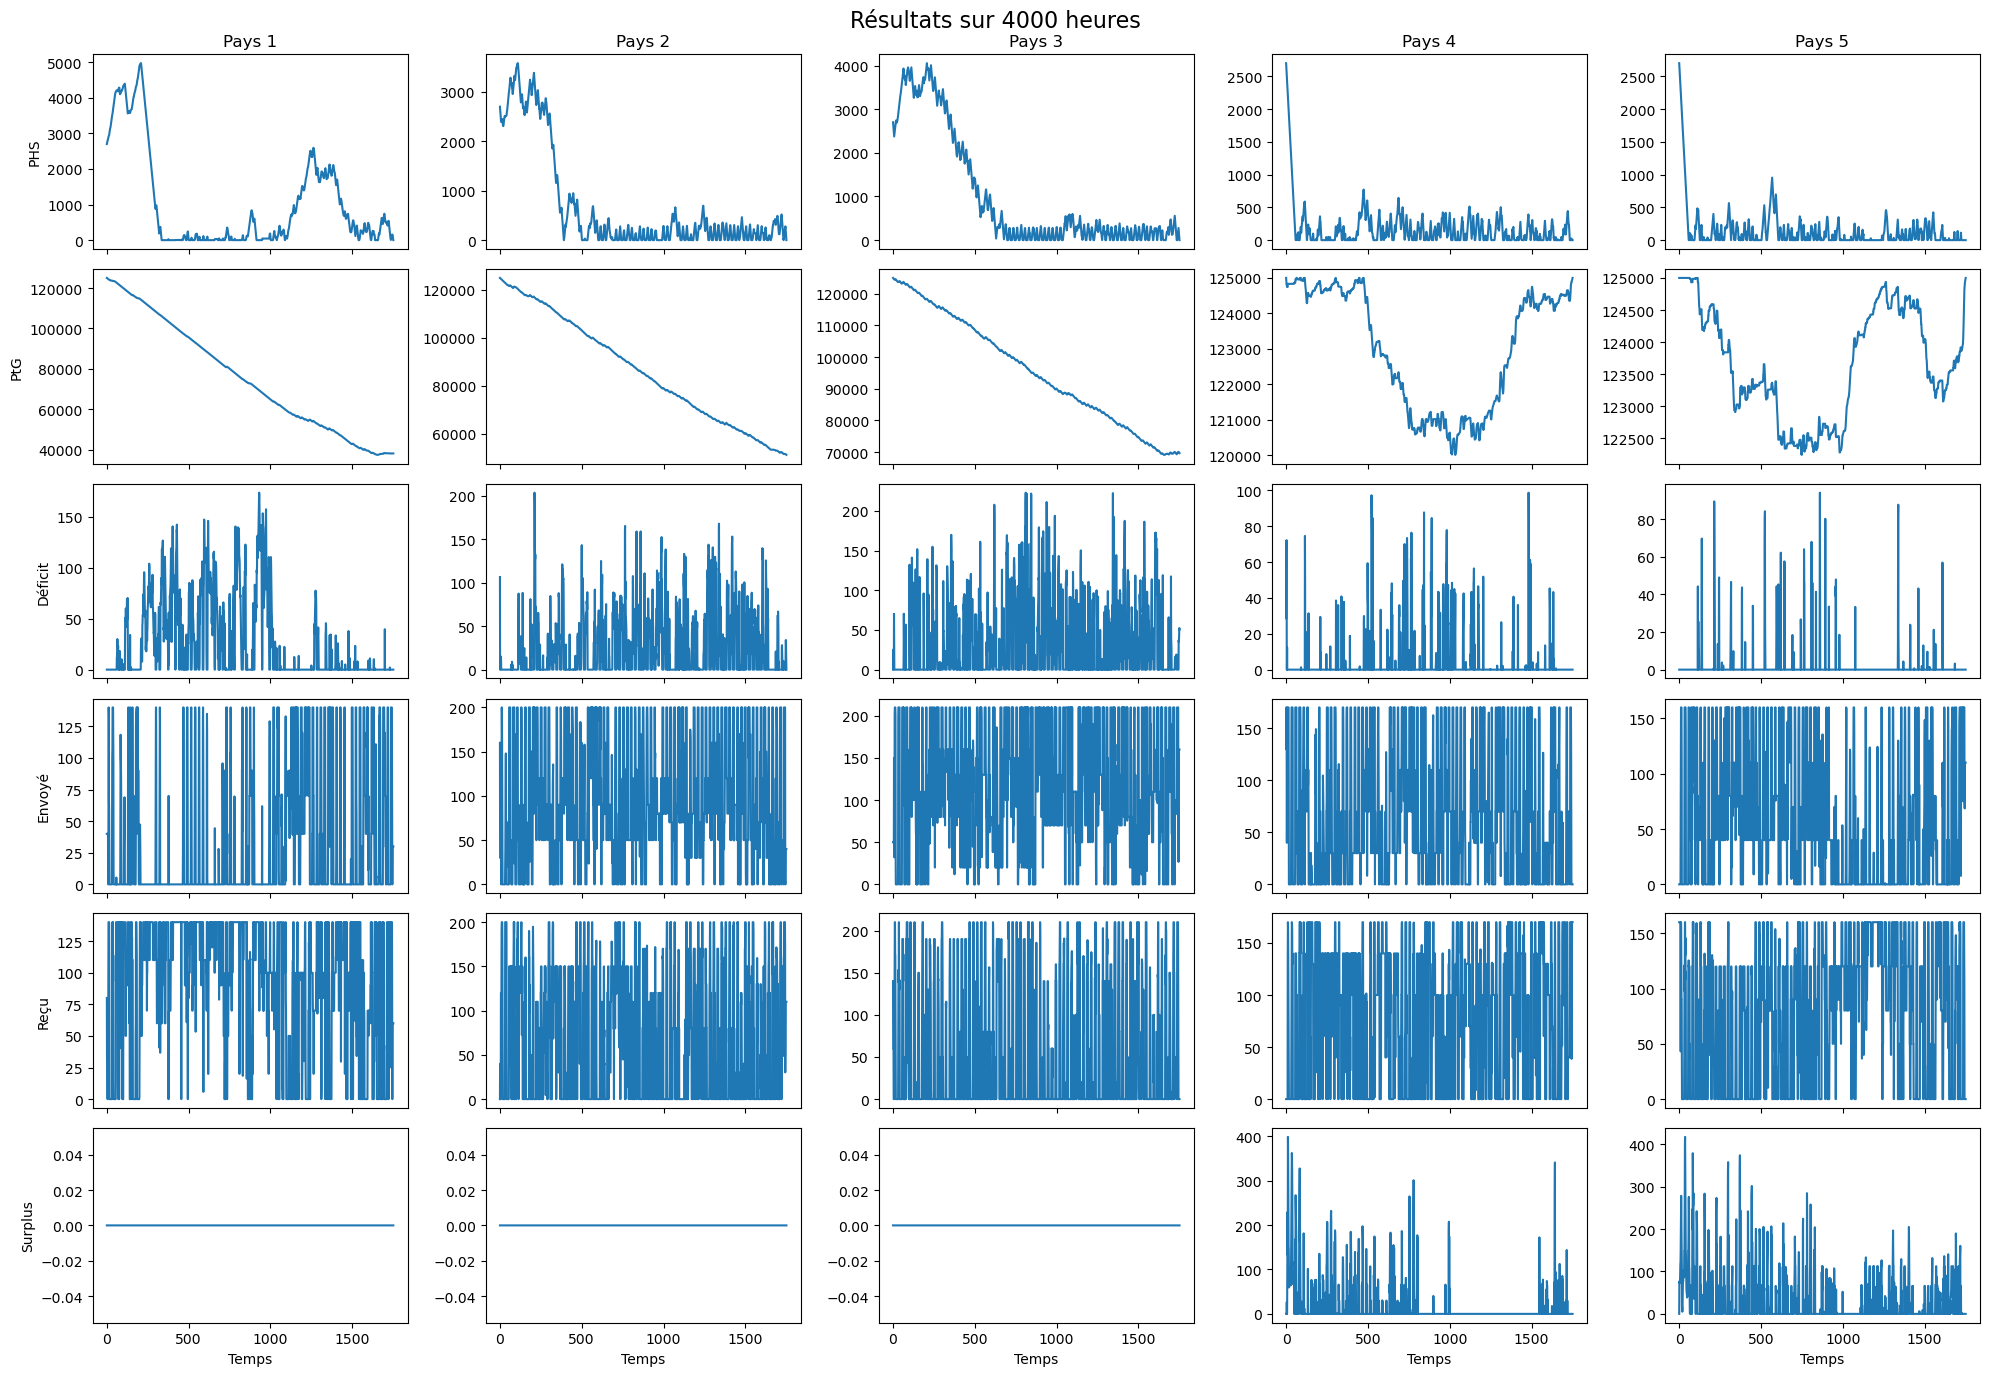

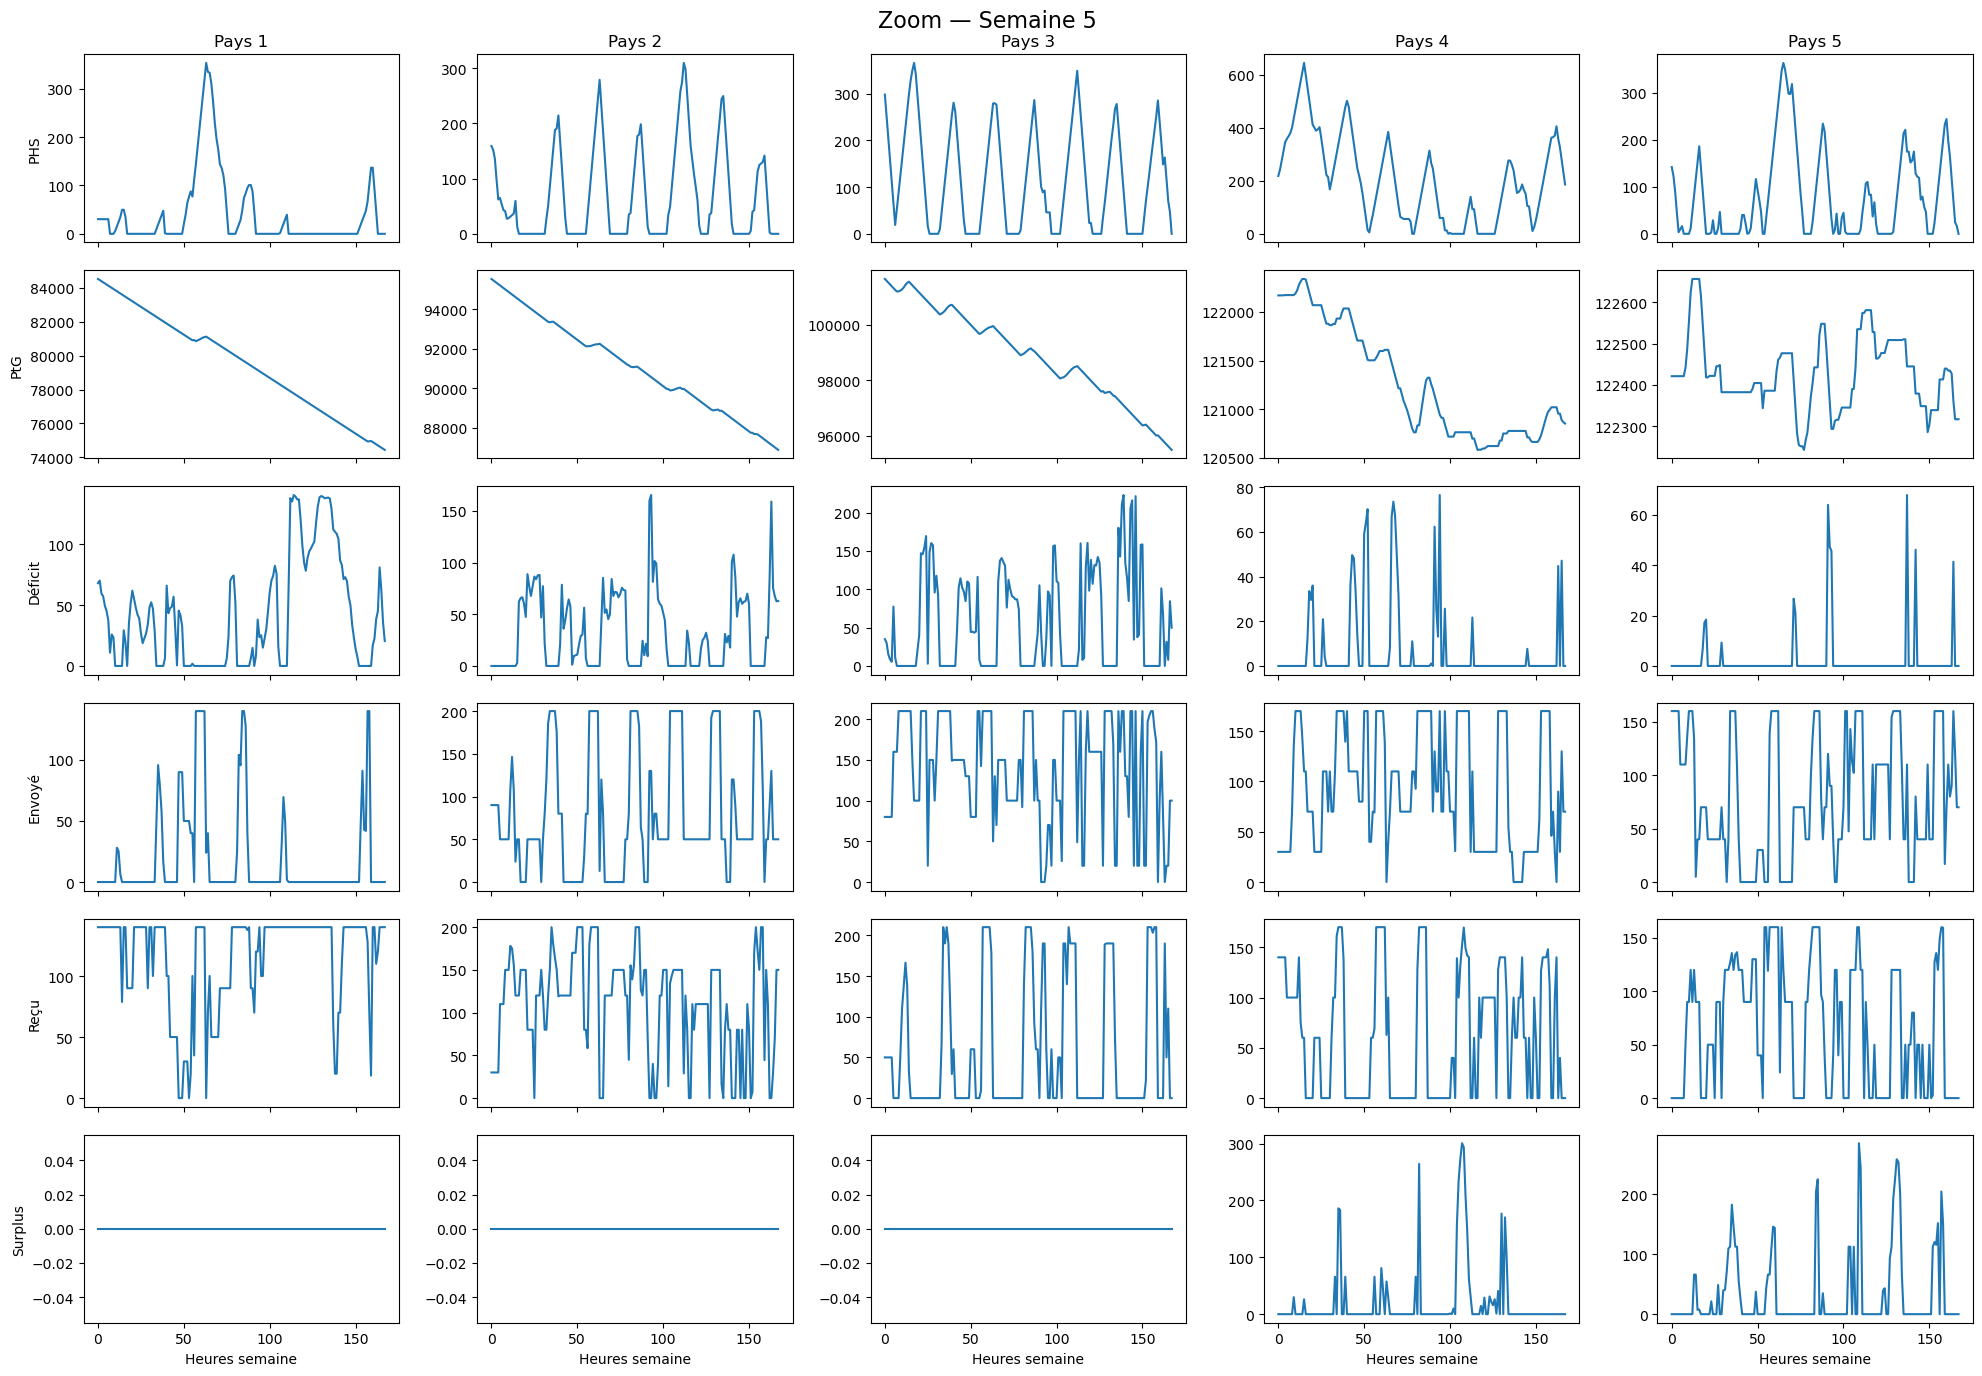

In [39]:
N = result['phs_level'].shape[1]

# --- Flux ---
q = result["echanges"]  # (T, N, N)
sent = np.sum(q, axis=2)
received = np.sum(q, axis=1)

# =====================================================
# GRAPHE GLOBAL (4000 heures)
# =====================================================
T_plot = 4000

fig, axes = plt.subplots(6, N, figsize=(20, 14), sharex=True)

for i in range(N):

    axes[0, i].plot(result['phs_level'][:T_plot, i])
    if i == 0: axes[0, i].set_ylabel("PHS")
    axes[0, i].set_title(f"Pays {i+1}")

    axes[1, i].plot(result['ptg_level'][:T_plot, i])
    if i == 0: axes[1, i].set_ylabel("PtG")

    axes[2, i].plot(result['deficit_final'][:T_plot, i])
    if i == 0: axes[2, i].set_ylabel("Déficit")

    axes[3, i].plot(sent[:T_plot, i])
    if i == 0: axes[3, i].set_ylabel("Envoyé")

    axes[4, i].plot(received[:T_plot, i])
    if i == 0: axes[4, i].set_ylabel("Reçu")

    axes[5, i].plot(result['surplus_final'][:T_plot, i])
    if i == 0: axes[5, i].set_ylabel("Surplus")
    axes[5, i].set_xlabel("Temps")

plt.suptitle("Résultats sur 4000 heures", fontsize=16)
plt.tight_layout()
plt.show()


# =====================================================
# ZOOM SEMAINE
# =====================================================
semaine = 5
T0 = 168 * (semaine - 1)
T1 = T0 + 168

fig, axes = plt.subplots(6, N, figsize=(20, 14), sharex=True)

for i in range(N):

    axes[0, i].plot(result['phs_level'][T0:T1, i])
    if i == 0: axes[0, i].set_ylabel("PHS")
    axes[0, i].set_title(f"Pays {i+1}")

    axes[1, i].plot(result['ptg_level'][T0:T1, i])
    if i == 0: axes[1, i].set_ylabel("PtG")

    axes[2, i].plot(result['deficit_final'][T0:T1, i])
    if i == 0: axes[2, i].set_ylabel("Déficit")

    axes[3, i].plot(sent[T0:T1, i])
    if i == 0: axes[3, i].set_ylabel("Envoyé")

    axes[4, i].plot(received[T0:T1, i])
    if i == 0: axes[4, i].set_ylabel("Reçu")
    
    axes[5, i].plot(result['surplus_final'][T0:T1, i])
    if i == 0: axes[5, i].set_ylabel("Surplus")
    axes[5, i].set_xlabel("Heures semaine")

plt.suptitle(f"Zoom — Semaine {semaine}", fontsize=16)
plt.tight_layout()
plt.show()


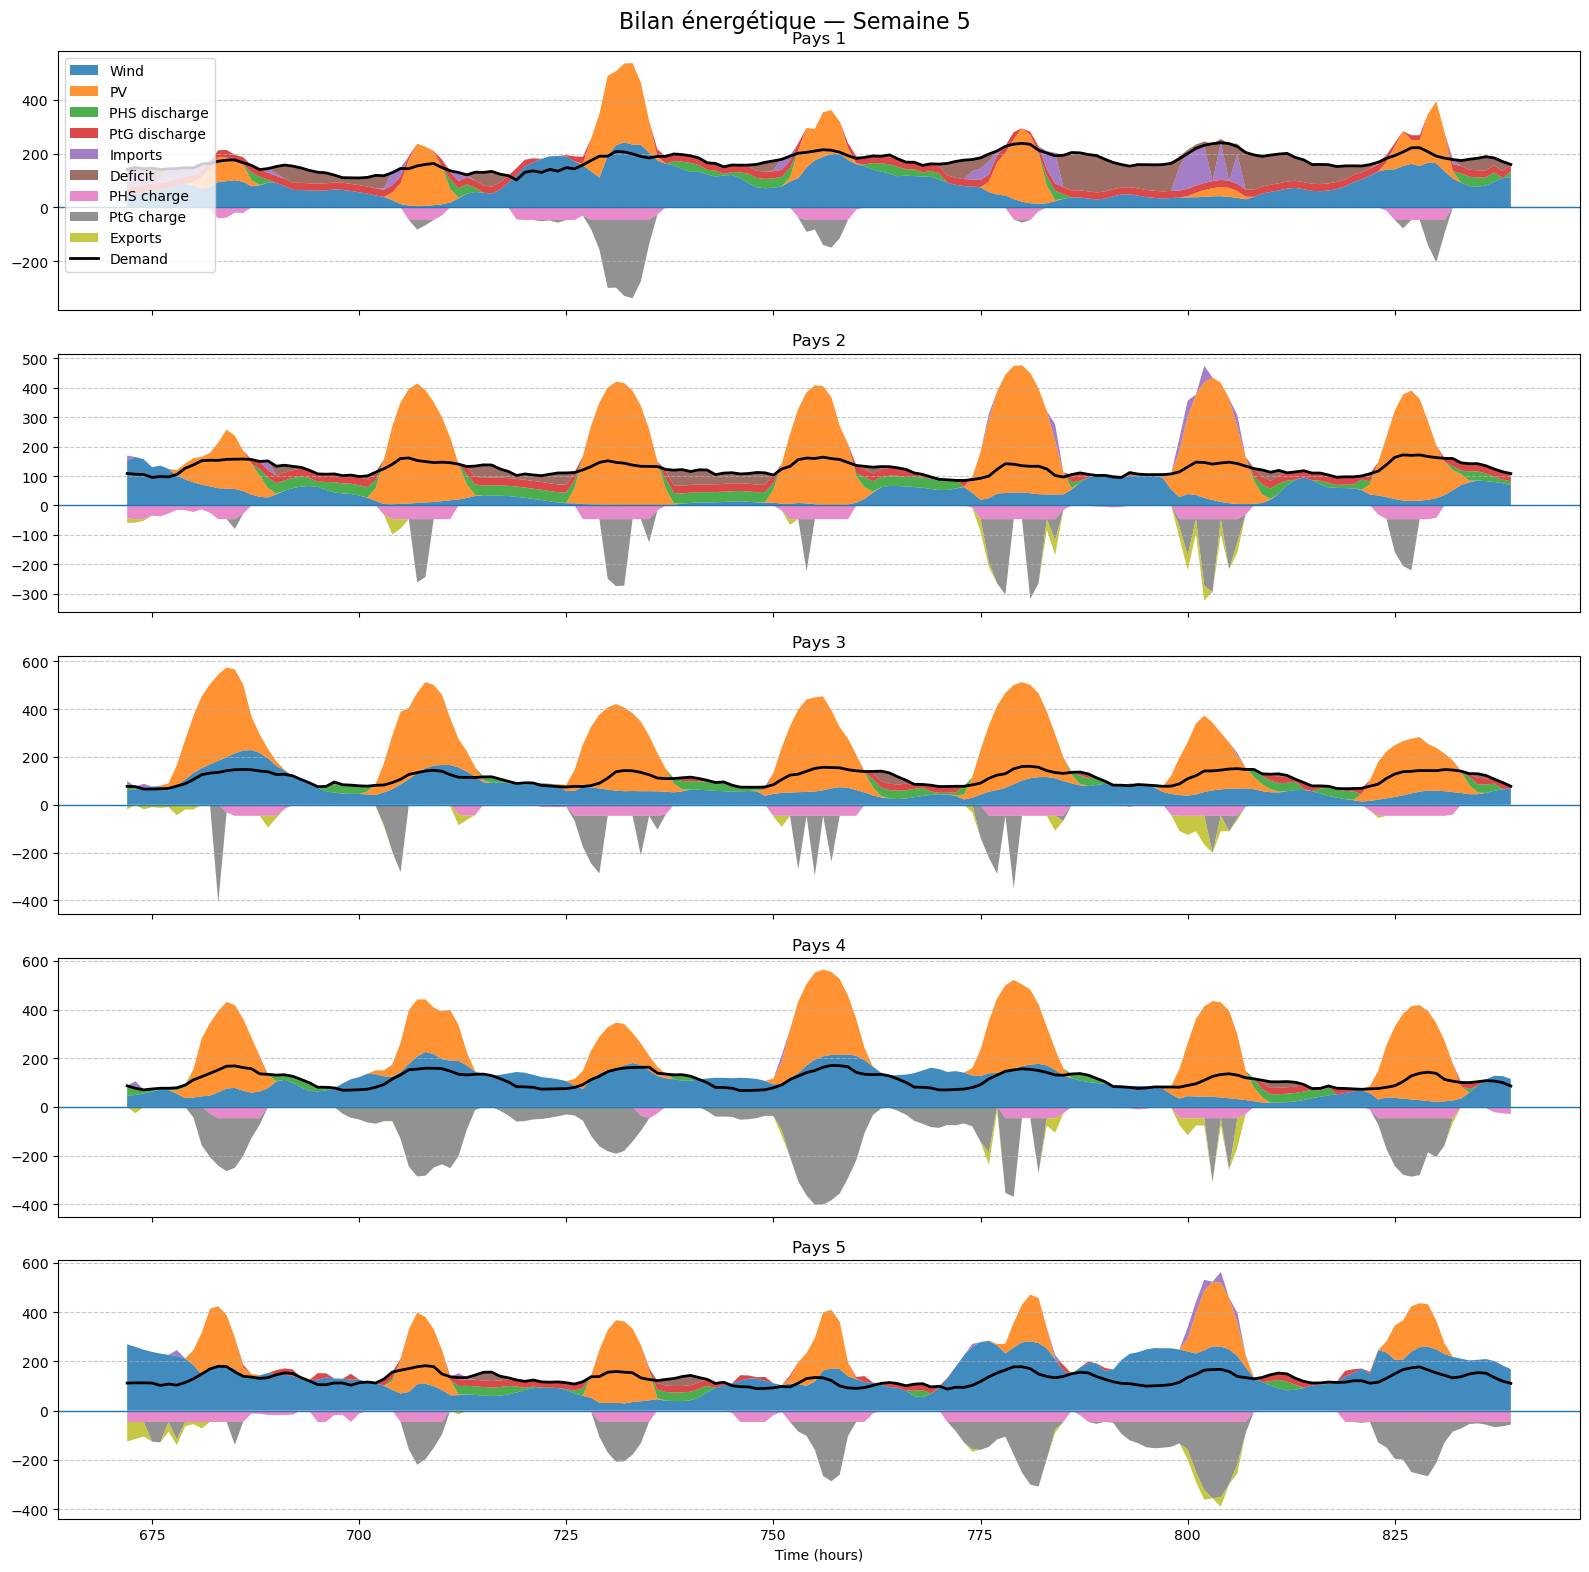

In [ ]:
# ===============================
# Flux échanges
# ===============================

ptg_eff=0.4
phs_eff = 0.75
time_axis = np.arange(T0, T1)

q = result["Echanges"]

imports = np.sum(q, axis=1)
exports = np.sum(q, axis=2)

fig, axes = plt.subplots(N, 1, figsize=(16, 16), sharex=True)

for i in range(N):

    # --- Production ---
    wind_i = (wind_N*wind_cap_N)[T0:T1, i]
    solar_i = (solar_N*solar_cap_N)[T0:T1, i]

    # --- Déstockage ---
    phs_dis = phs_eff * result['phs_out'][T0:T1, i]
    ptg_dis = ptg_eff * result['ptg_out'][T0:T1, i]

    # --- Stockage (négatif) ---
    phs_ch = -result['phs_in'][T0:T1, i]
    ptg_ch = -result['ptg_in'][T0:T1, i]

    # --- Echanges ---
    import_i = imports[T0:T1, i]
    export_i = -exports[T0:T1, i]   # NEGATIF

    deficit_i = result['deficit'][T0:T1, i]
    demand_i = demand_N[T0:T1, i]

    # ===== STACK POSITIF =====
    stack_pos = [
        wind_i,
        solar_i,
        phs_dis,
        ptg_dis,
        import_i,
        deficit_i
    ]

    labels_pos = [
        'Wind',
        'PV',
        'PHS discharge',
        'PtG discharge',
        'Imports',
        'Deficit'
    ]

    axes[i].stackplot(time_axis, stack_pos, alpha=0.85)

    # ===== STACK NEGATIF =====
    stack_neg = [
        phs_ch,
        ptg_ch,
        export_i
    ]

    axes[i].stackplot(time_axis, stack_neg, alpha=0.85)

    # --- Demande ---
    axes[i].plot(time_axis,
                 demand_i,
                 color='black',
                 linewidth=2,
                 label='Demand')

    axes[i].axhline(0, linewidth=1)

    axes[i].set_title(f"Pays {i+1}")
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    if i == 0:
        axes[i].legend(labels_pos + ['PHS charge','PtG charge','Exports','Demand'],
                       loc='upper left', fontsize=10)

axes[-1].set_xlabel("Time (hours)")
plt.suptitle(f"Bilan énergétique — Semaine {semaine}", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
def compute_static_pos(qmax_matrix):
    N = qmax_matrix.shape[0]
    G = nx.DiGraph()

    # Création structure graphique
    for i in range(N):
        G.add_node(i)
    for i in range(N):
        for j in range(N):
            if i != j and qmax_matrix[i, j] > 0:
                G.add_edge(i, j)

    return nx.spring_layout(G, seed=42)


def show_graphs(prod_matrix, demand_matrix, qmax_matrix,
                q_array, r_pos_array, r_neg_array,
                pos, period=0):

    T, N = prod_matrix.shape

    # ===== Graphe Capacités qmax =====
    G1 = nx.DiGraph()
    Q = prod_matrix[period] - demand_matrix[period]

    for i in range(N):
        G1.add_node(i, Q=Q[i])
    for i in range(N):
        for j in range(N):
            if i != j and qmax_matrix[i, j] > 0:
                G1.add_edge(i, j, qmax=qmax_matrix[i, j])

    node_colors1 = ["#6BC729" if Q[i] >= 0 else "#F77260" for i in G1.nodes()]
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Taille des arêtes FIXE
    nx.draw(G1, pos, ax=axes[0], node_color=node_colors1,
            node_size=4500, width=2, edge_color="#7D7D7D",
            arrowsize=20)

    # Labels noeuds
    labels1 = {i: f"P{i}\nQ={Q[i]:.1f}" for i in G1.nodes()}
    nx.draw_networkx_labels(
        G1, pos,
        labels=labels1,
        font_size=13,
        font_weight="bold",
        ax=axes[0]
    )

    # Labels arêtes qmax
    edge_labels1 = {(i, j): f"{G1.edges[i, j]['qmax']:.1f}" for i, j in G1.edges()}
    nx.draw_networkx_edge_labels(
        G1, pos,
        edge_labels=edge_labels1,
        font_size=15,
        font_weight="bold",
        ax=axes[0]
    )

    axes[0].set_title(f"Capacités qmax - Période {period}")


    # ===== Graphe flux réels =====
    G2 = nx.DiGraph()
    for i in range(N):
        r = r_pos_array[period, i] - r_neg_array[period, i]
        G2.add_node(i, r=r)
    for i in range(N):
        for j in range(N):
            v = q_array[period, i, j]
            if i != j and v > 1e-6:
                G2.add_edge(i, j, flux=v)

    node_colors2 = ['#6BC729' if G2.nodes[i]['r'] >= 0 else "#F77260" for i in G2.nodes()]
    nx.draw(G2, pos, ax=axes[1], node_color=node_colors2,
            node_size=4500, width=2,
            edge_color="#337FEA", arrowsize=20)

    labels2 = {i: f"P{i}\nr={G2.nodes[i]['r']:.2f}" for i in G2.nodes()}
    nx.draw_networkx_labels(
        G2, pos,
        labels=labels2,
        font_size=13,
        font_weight="bold",
        ax=axes[1]
    )

    # Labels arêtes flux
    edge_labels2 = {(i, j): f"{G2.edges[i, j]['flux']:.2f}" for i, j in G2.edges()}
    nx.draw_networkx_edge_labels(
        G2, pos,
        edge_labels=edge_labels2,
        font_size=15,
        font_weight="bold",
        ax=axes[1]
    )


    axes[1].set_title("Flux optimisés")

    plt.show()



# === Fonction interactive finale ===
def interactive_graphs(prod, dem, qmax, q, r_pos, r_neg):
    pos = compute_static_pos(qmax)
    T = prod.shape[0]

    interact(lambda period: show_graphs(prod, dem, qmax, q, r_pos, r_neg, pos, period),
             period=IntSlider(min=0, max=T-1, step=1, value=0, description="Temps"))

In [ ]:
interactive_graphs(result['surplus avant echange'], result['deficit avant echange'], qmax, q, result['surplus'], result['deficit'])

interactive(children=(IntSlider(value=0, description='Temps', max=1751), Output()), _dom_classes=('widget-inte…